# CS439 Final Project Exploration Notebook

This notebook is the interactive version of the project pipeline. It is meant for exploring the IMDb movies dataset, checking the cleaning steps, viewing plots inline, and understanding the model results.

The final reproducible version should still be in `src/final_project_analysis.py`.


## 1. Setup

Run this notebook from the project root in VSCode/Jupyter. The expected project structure is:

```text
DataScienceProject/
├── data/
│   └── imdb_movies.csv
├── notebooks/
│   └── final_project_exploration.ipynb
├── outputs/
├── src/
│   └── final_project_analysis.py
├── README.md
└── requirements.txt
```


In [261]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

# If this notebook is inside notebooks/, parents[1] is the project root.
# If this cell errors because of the path, set PROJECT_ROOT manually to your repo folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "imdb_movies.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())


Project root: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject
Data path: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\data\imdb_movies.csv
Data exists: True


## 2. Load the Raw Dataset

This section checks what the dataset looks like before cleaning.


In [262]:
raw_df = pd.read_csv(DATA_PATH)

print("Shape:", raw_df.shape)
display(raw_df.head())
raw_df.info()


Shape: (10178, 12)


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


In [263]:
# Missing values by column
missing = raw_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


genre    85
crew     56
dtype: int64

In [264]:
# Quick numeric and categorical summary
display(raw_df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
names,10178,9660,Pinocchio,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_x,10178,5688,04/07/2023,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,10178.0,NaN,NaN,NaN,63.497052,13.537012,0.0,59.0,65.0,71.0,100.0
genre,10093,2303,Drama,556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,10178,9905,We don't have an overview translated in Englis...,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crew,10122,9927,"Benjamin Evan Ainsworth, Pinocchio (voice), To...",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orig_title,10178,9736,Pinocchio,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,10178,3,Released,10131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orig_lang,10178,54,English,7417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
budget_x,10178.0,NaN,NaN,NaN,64882378.890922,57075645.275288,1.0,15000000.0,50000000.0,105000000.0,460000000.0


## 3. Cleaning and Feature Engineering

The goal here is to create a clean modeling table while keeping the transformations easy to explain in the report.

Main steps:
- Rename columns to clearer names.
- Parse the release date.
- Extract release year.
- Normalize text/categorical values.
- Create financial features like profit, ROI, and log-transformed budget/revenue.
- Keep released movies with valid scores and financial values.


In [265]:
def normalize_text(value: object) -> str:
    if pd.isna(value):
        return "Unknown"
    text = str(value).replace("\xa0", " ").strip()
    return text if text else "Unknown"


def load_and_clean_data(data_path: Path) -> pd.DataFrame:
    df = pd.read_csv(data_path)

    df = df.rename(
        columns={
            "names": "title",
            "date_x": "release_date",
            "budget_x": "budget",
            "orig_lang": "language",
        }
    )

    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df["release_year"] = df["release_date"].dt.year

    df["genre"] = df["genre"].apply(normalize_text)
    df["main_genre"] = df["genre"].str.split(",").str[0].apply(normalize_text)
    df["language"] = df["language"].apply(normalize_text)
    df["country"] = df["country"].apply(normalize_text)
    df["status"] = df["status"].apply(normalize_text)

    numeric_cols = ["score", "budget", "revenue"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["profit"] = df["revenue"] - df["budget"]
    df["roi"] = np.where(df["budget"] > 0, df["profit"] / df["budget"], np.nan)

    roi_clean = df["roi"].replace([np.inf, -np.inf], np.nan)
    roi_bounds = roi_clean.quantile([0.01, 0.99])
    df["roi_capped"] = df["roi"].clip(
        lower=roi_bounds.loc[0.01],
        upper=roi_bounds.loc[0.99],
    )

    df["log_budget"] = np.log1p(df["budget"].clip(lower=0))
    df["log_revenue"] = np.log1p(df["revenue"].clip(lower=0))
    df["log_profit_shifted"] = np.log1p((df["profit"] - df["profit"].min()).clip(lower=0))

    cleaned = df[df["status"].eq("Released")].copy()
    cleaned = cleaned.dropna(subset=["score", "budget", "revenue"])
    cleaned = cleaned[
        (cleaned["score"] > 0)
        & (cleaned["budget"] >= 0)
        & (cleaned["revenue"] >= 0)
    ]

    return cleaned


df = load_and_clean_data(DATA_PATH)

print("Cleaned shape:", df.shape)
display(df.head())
display(df[["score", "budget", "revenue", "profit", "roi", "release_year"]].describe().T)


Cleaned shape: (9967, 20)


,title,release_date,score,genre,overview,crew,orig_title,status,language,budget,revenue,country,release_year,main_genre,profit,roi,roi_capped,log_budget,log_revenue,log_profit_shifted
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,2023,Drama,1.966167e+08,2.621556,2.621556,18.132999,19.419902,20.100795
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,2022,Science Fiction,1.856795e+09,4.036511,4.036511,19.946737,21.563451,21.510265
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,2023,Animation,6.244590e+08,6.244590,6.244590,18.420681,20.400936,20.687078
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,2023,Animation,2.190000e+07,1.780488,1.780488,16.325110,17.347736,19.706878
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,2023,Action,2.639420e+08,3.427818,3.427818,18.159316,19.647223,20.218989


,count,mean,std,min,25%,50%,75%,max
score,9967.0,6.484128e+01,9.998028e+00,10.0,6.000000e+01,6.600000e+01,7.200000e+01,1.000000e+02
budget,9967.0,6.235943e+07,5.427906e+07,1.0,1.400000e+07,5.000000e+07,1.020000e+08,4.600000e+08
revenue,9967.0,2.551060e+08,2.802254e+08,0.0,2.758163e+07,1.453741e+08,4.260998e+08,2.923706e+09
profit,9967.0,1.927465e+08,2.433585e+08,-199548822.0,7.520869e+06,9.133898e+07,3.244516e+08,2.686706e+09
roi,9967.0,3.025915e+04,2.594396e+06,-1.0,5.129363e-01,2.363703e+00,4.913364e+00,2.577204e+08
release_year,9967.0,2.007687e+03,1.533475e+01,1903.0,2.001000e+03,2.013000e+03,2.019000e+03,2.023000e+03


In [266]:
# Save the cleaned data for later report/code use.
df.to_csv(OUTPUT_DIR / "cleaned_movies.csv", index=False)
print("Saved:", OUTPUT_DIR / "cleaned_movies.csv")


Saved: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\outputs\cleaned_movies.csv


## 4. Exploratory Data Analysis

These plots are mostly for understanding the dataset and finding useful visuals for the report.


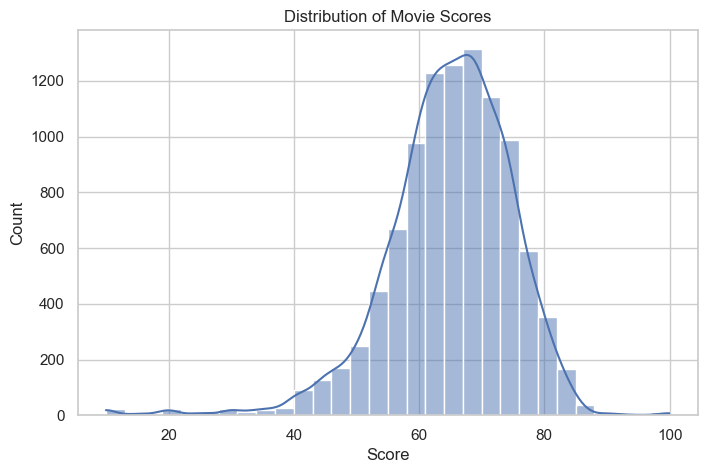

In [267]:
plt.figure(figsize=(8, 5))
sns.histplot(df["score"], bins=30, kde=True)
plt.title("Distribution of Movie Scores")
plt.xlabel("Score")
plt.show()


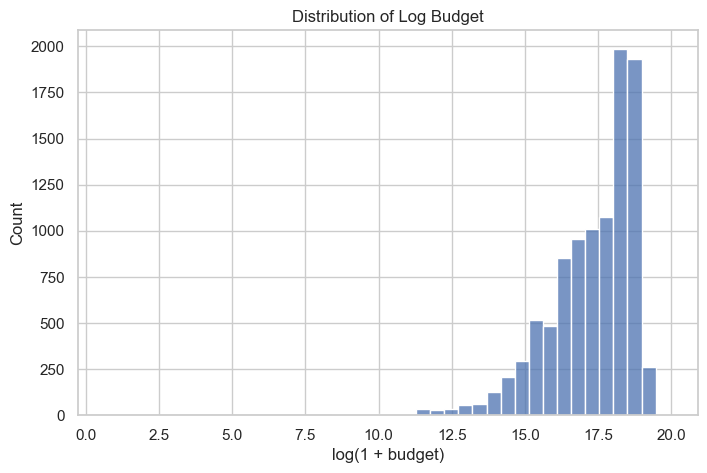

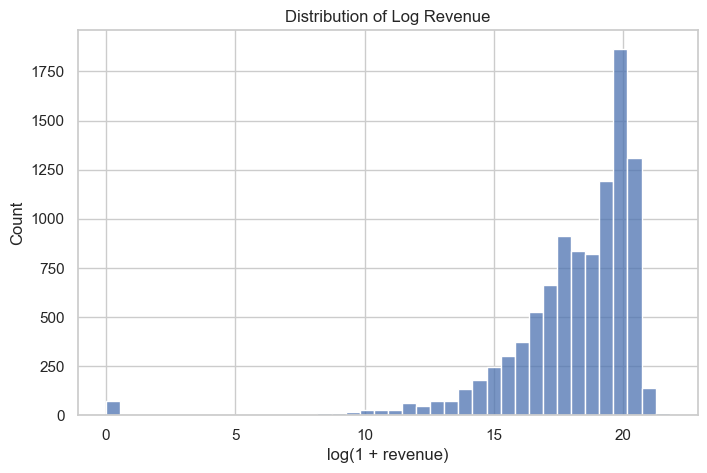

In [268]:
plt.figure(figsize=(8, 5))
sns.histplot(df["log_budget"], bins=40)
plt.title("Distribution of Log Budget")
plt.xlabel("log(1 + budget)")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["log_revenue"], bins=40)
plt.title("Distribution of Log Revenue")
plt.xlabel("log(1 + revenue)")
plt.show()


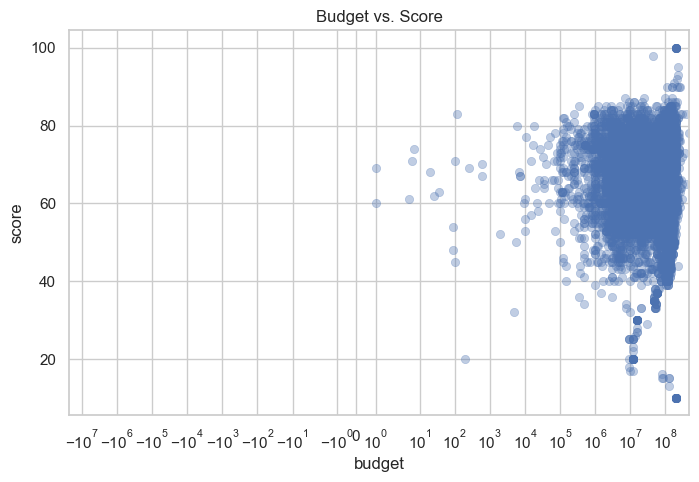

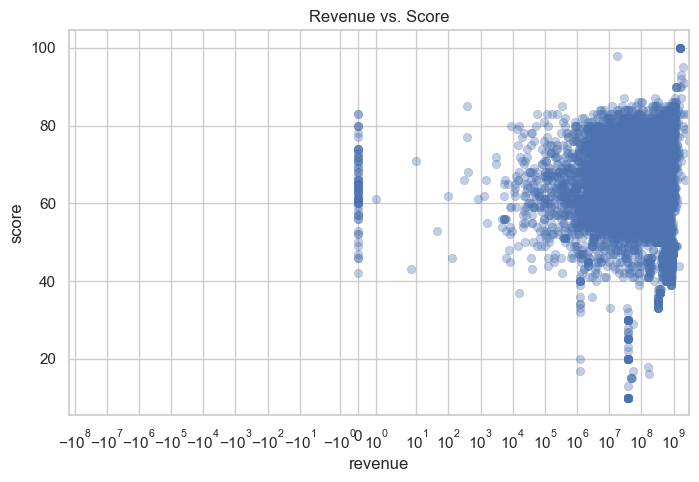

In [269]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="budget", y="score", alpha=0.35, edgecolor=None)
plt.xscale("symlog")
plt.title("Budget vs. Score")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="revenue", y="score", alpha=0.35, edgecolor=None)
plt.xscale("symlog")
plt.title("Revenue vs. Score")
plt.show()


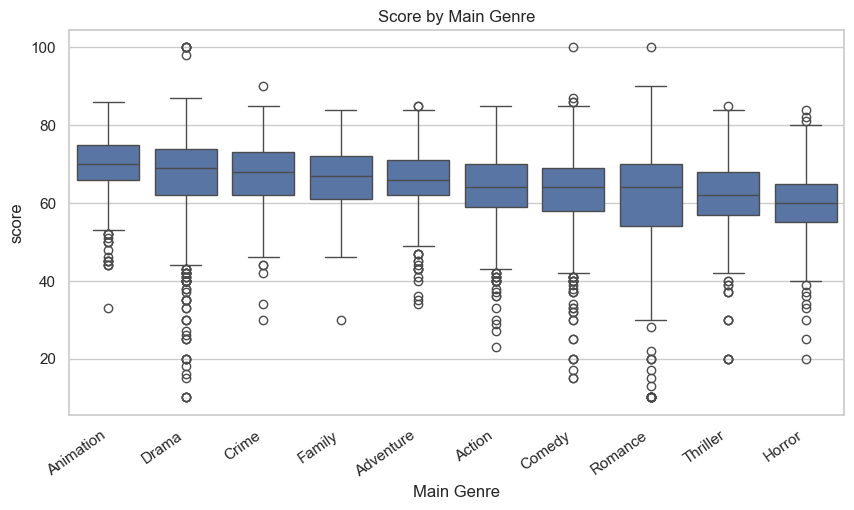

In [270]:
top_genres = df["main_genre"].value_counts().head(10).index
genre_subset = df[df["main_genre"].isin(top_genres)].copy()

plt.figure(figsize=(10, 5))
genre_order = (
    genre_subset.groupby("main_genre")["score"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(data=genre_subset, x="main_genre", y="score", order=genre_order)
plt.title("Score by Main Genre")
plt.xlabel("Main Genre")
plt.xticks(rotation=35, ha="right")
plt.show()


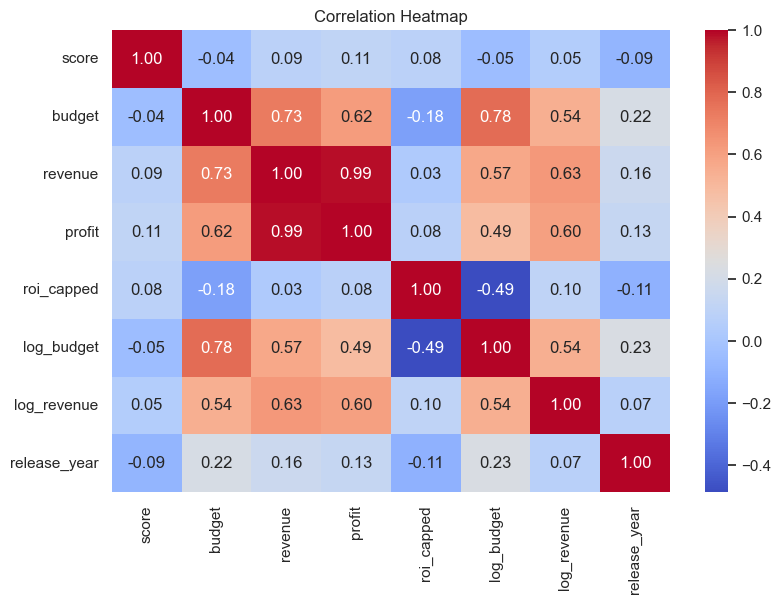

In [271]:
numeric_cols = [
    "score",
    "budget",
    "revenue",
    "profit",
    "roi_capped",
    "log_budget",
    "log_revenue",
    "release_year",
]

plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 5. Modeling Helper Functions

These helper functions are used by the regression and classification sections.


In [272]:
def make_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
) -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )


def regression_metrics(y_true: pd.Series, preds: np.ndarray, model_name: str) -> dict[str, float]:
    return {
        "model": model_name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, preds))),
        "mae": float(mean_absolute_error(y_true, preds)),
        "r2": float(r2_score(y_true, preds)),
    }


## 6. Regression Baselines

We start with simple baselines before adding more features.

- **Mean predictor:** always predicts the average score from the training set.
- **Basic linear regression:** uses only budget and revenue.


In [273]:
def mean_score_baseline(df: pd.DataFrame) -> dict[str, float]:
    X = df[["budget", "revenue"]]
    y = df["score"]

    _, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    mean_prediction = y_train.mean()
    preds = np.full(shape=len(y_test), fill_value=mean_prediction)

    return regression_metrics(y_test, preds, "Mean score baseline")


def basic_linear_regression(df: pd.DataFrame) -> dict[str, float]:
    X = df[["budget", "revenue"]]
    y = df["score"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("regressor", LinearRegression()),
        ]
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return regression_metrics(y_test, preds, "Basic linear regression")


mean_result = mean_score_baseline(df)
basic_lr_result = basic_linear_regression(df)

display(pd.DataFrame([mean_result, basic_lr_result]))


,model,rmse,mae,r2
0,Mean score baseline,10.329464,7.717587,-0.000517
1,Basic linear regression,10.121755,7.547621,0.039316


## 7. Improved Linear Regression

This version adds engineered numerical features and categorical features.

Numerical features:
- `log_budget`
- `log_revenue`
- `profit`
- `roi_capped`
- `release_year`

Categorical features:
- `main_genre`
- `language`
- `country`


In [274]:
def improved_regression(df: pd.DataFrame) -> tuple[dict[str, float], Pipeline]:
    numeric_features = [
        "log_budget",
        "log_revenue",
        "profit",
        "roi_capped",
        "release_year",
    ]
    categorical_features = ["main_genre", "language", "country"]

    X = df[numeric_features + categorical_features]
    y = df["score"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    model = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
            ("regressor", LinearRegression()),
        ]
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return regression_metrics(y_test, preds, "Improved linear regression"), model


improved_result, improved_model = improved_regression(df)

regression_results = [mean_result, basic_lr_result, improved_result]
display(pd.DataFrame(regression_results))


,model,rmse,mae,r2
0,Mean score baseline,10.329464,7.717587,-0.000517
1,Basic linear regression,10.121755,7.547621,0.039316
2,Improved linear regression,9.198042,6.723644,0.206659


In [275]:
# Save regression results
pd.DataFrame(regression_results).to_csv(OUTPUT_DIR / "regression_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "regression_results.csv")


Saved: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\outputs\regression_results.csv


# 8. adding medium


In [276]:
# 3-category classification model

data = df.copy()

data["score_category"] = pd.cut(
    data["score"],
    bins=[0, 60, 75, 100],
    labels=["low", "medium", "high"],
    include_lowest=True,
)

data = data.dropna(subset=["score_category"])

print("Score category counts:")
display(data["score_category"].value_counts())

print("\nScore category proportions:")
display(data["score_category"].value_counts(normalize=True))

numeric_features = [
    "log_budget",
    "log_revenue",
    "log_profit_shifted",
    "roi_capped",
    "release_year",
]

categorical_features = ["main_genre", "language", "country"]

X = data[numeric_features + categorical_features]
y = data["score_category"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

classification_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

classification_pipeline.fit(X_train, y_train)
classification_preds = classification_pipeline.predict(X_test)

classification_results = {
    "model": "Logistic regression classification: low / medium / high score",
    "accuracy": accuracy_score(y_test, classification_preds),
    "precision_macro": precision_score(
        y_test, classification_preds, average="macro", zero_division=0
    ),
    "recall_macro": recall_score(
        y_test, classification_preds, average="macro", zero_division=0
    ),
    "f1_macro": f1_score(
        y_test, classification_preds, average="macro", zero_division=0
    ),
    "precision_weighted": precision_score(
        y_test, classification_preds, average="weighted", zero_division=0
    ),
    "recall_weighted": recall_score(
        y_test, classification_preds, average="weighted", zero_division=0
    ),
    "f1_weighted": f1_score(
        y_test, classification_preds, average="weighted", zero_division=0
    ),
}

classification_results

Score category counts:


score_category
medium    5932
low       2868
high      1167
Name: count, dtype: int64


Score category proportions:


score_category
medium    0.595164
low       0.287750
high      0.117086
Name: proportion, dtype: float64

{'model': 'Logistic regression classification: low / medium / high score',
 'accuracy': 0.4448345035105316,
 'precision_macro': 0.43319949863548174,
 'recall_macro': 0.5057776642476236,
 'f1_macro': 0.430606040445255,
 'precision_weighted': 0.5238700416875491,
 'recall_weighted': 0.4448345035105316,
 'f1_weighted': 0.45427755468911285}

In [277]:
confusion = pd.crosstab(
    y_test,
    classification_preds,
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False,
)

confusion

Predicted,high,low,medium
Actual,,,
high,145,31,57
low,68,300,206
medium,364,381,442


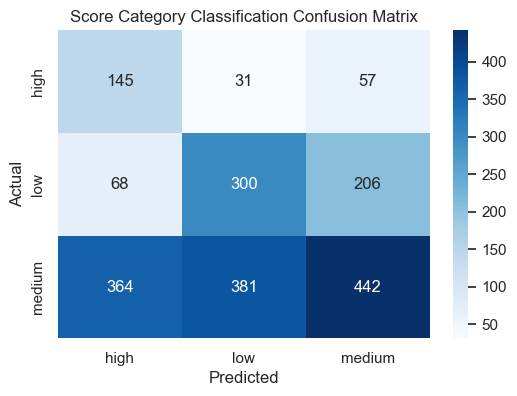

In [278]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Score Category Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. Classification Version: High-Rated vs. Not High-Rated

This is optional, but it lets us use classification metrics from class.

For now, a movie is labeled high-rated if:

```text
score >= 75
```

We should check whether this threshold creates a reasonable class balance.


In [279]:
df["score"].describe()

pd.cut(
    df["score"],
    bins=[0, 60, 75, 100],
    labels=["low", "medium", "high"]
).value_counts(normalize=True)

df["score_category"] = pd.qcut(
    df["score"],
    q=3,
    labels=["low", "medium", "high"]
)

high_score_threshold = 75
df["high_rated"] = (df["score"] >= high_score_threshold).astype(int)

print("Positive rate:", df["high_rated"].mean())
display(df["high_rated"].value_counts(normalize=True).rename("proportion"))


Positive rate: 0.14648339520417378


high_rated
0    0.853517
1    0.146483
Name: proportion, dtype: float64

In [280]:
def classification_model(df: pd.DataFrame, high_score_threshold: int = 75) -> dict[str, float]:
    data = df.copy()
    data["high_rated"] = (data["score"] >= high_score_threshold).astype(int)

    numeric_features = ["log_budget", "log_revenue", "profit", "roi_capped", "release_year"]
    categorical_features = ["main_genre", "language", "country"]

    X = data[numeric_features + categorical_features]
    y = data["high_rated"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    model = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "model": f"Logistic regression classification score >= {high_score_threshold}",
        "accuracy": float(accuracy_score(y_test, preds)),
        "precision": float(precision_score(y_test, preds, zero_division=0)),
        "recall": float(recall_score(y_test, preds, zero_division=0)),
        "f1": float(f1_score(y_test, preds, zero_division=0)),
        "positive_rate": float(y.mean()),
    }


classification_result = classification_model(df, high_score_threshold=75)
display(pd.DataFrame([classification_result]))


,model,accuracy,precision,recall,f1,positive_rate
0,Logistic regression classification score >= 75,0.695587,0.280335,0.688356,0.398414,0.146483


## 9. K-Means Clustering + PCA Visualization

This section uses unsupervised learning to group movies based on metadata and financial features.

Important note: this clustering version **does not include `score` as an input feature**. That way, we can compare the average score of clusters afterward without having score directly influence the clusters.


In [281]:
def clustering_and_pca(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, PCA]:
    numeric_features = [
        "log_budget",
        "log_revenue",
        "profit",
        "roi_capped",
        "release_year",
    ]
    categorical_features = ["main_genre", "language", "country"]
    features = numeric_features + categorical_features

    preprocessor = make_preprocessor(numeric_features, categorical_features)
    X_processed = preprocessor.fit_transform(df[features])

    kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(X_processed)

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    components = pca.fit_transform(X_processed)

    clustered = df.copy()
    clustered["cluster"] = labels
    clustered["pca_1"] = components[:, 0]
    clustered["pca_2"] = components[:, 1]

    profile = (
        clustered.groupby("cluster")
        .agg(
            movie_count=("title", "count"),
            avg_score=("score", "mean"),
            median_budget=("budget", "median"),
            median_revenue=("revenue", "median"),
            median_profit=("profit", "median"),
            median_roi=("roi", "median"),
            median_year=("release_year", "median"),
            top_genre=("main_genre", lambda s: s.value_counts().index[0]),
            top_language=("language", lambda s: s.value_counts().index[0]),
            top_country=("country", lambda s: s.value_counts().index[0]),
        )
        .round(3)
        .reset_index()
    )

    return clustered, profile, pca


clustered_df, cluster_profile, pca_model = clustering_and_pca(df)

display(cluster_profile)


,cluster,movie_count,avg_score,median_budget,median_revenue,median_profit,median_roi,median_year,top_genre,top_language,top_country
0,0,195,67.862,450000.0,100216295.0,99550000.0,127.860,2009.0,Drama,English,AU
1,1,4058,63.981,20000000.0,30634230.0,7000000.0,0.475,2013.0,Drama,English,AU
2,2,1690,66.297,22000000.0,62573095.0,41288436.0,2.258,1986.0,Drama,English,AU
3,3,4024,64.951,107500000.0,475045998.5,369451697.3,3.588,2017.0,Action,English,AU


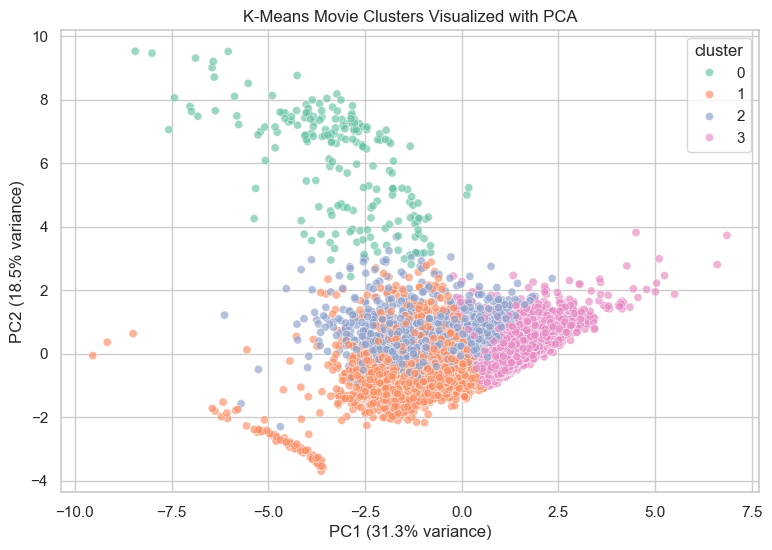

Total variance shown by first two PCs: 0.4978475012212694


In [282]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clustered_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="Set2",
    alpha=0.65,
    s=35,
)
plt.title("K-Means Movie Clusters Visualized with PCA")
plt.xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} variance)")
plt.show()

print("Total variance shown by first two PCs:", pca_model.explained_variance_ratio_.sum())


In [283]:
# Save clustering outputs
cluster_profile.to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)

clustered_df[
    ["title", "score", "budget", "revenue", "main_genre", "language", "country", "cluster"]
].to_csv(OUTPUT_DIR / "movies_with_clusters.csv", index=False)

print("Saved:", OUTPUT_DIR / "cluster_profiles.csv")
print("Saved:", OUTPUT_DIR / "movies_with_clusters.csv")


Saved: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\outputs\cluster_profiles.csv
Saved: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\outputs\movies_with_clusters.csv


## 10. Save Final Combined Model Results

This cell saves the main regression and classification results together.


In [284]:
all_results = regression_results + [classification_result]

pd.DataFrame(all_results).to_csv(OUTPUT_DIR / "model_results.csv", index=False)

with open(OUTPUT_DIR / "model_results.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

display(pd.DataFrame(all_results))
print("Saved:", OUTPUT_DIR / "model_results.csv")
print("Saved:", OUTPUT_DIR / "model_results.json")


,model,rmse,mae,r2,accuracy,precision,recall,f1,positive_rate
0,Mean score baseline,10.329464,7.717587,-0.000517,NaN,NaN,NaN,NaN,NaN
1,Basic linear regression,10.121755,7.547621,0.039316,NaN,NaN,NaN,NaN,NaN
2,Improved linear regression,9.198042,6.723644,0.206659,NaN,NaN,NaN,NaN,NaN
3,Logistic regression classification score >= 75,NaN,NaN,NaN,0.695587,0.280335,0.688356,0.398414,0.146483


Saved: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\outputs\model_results.csv
Saved: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\outputs\model_results.json


In [285]:
(df["budget"] == 0).mean()
(df["revenue"] == 0).mean()
df["score"].describe()

count    9967.000000
mean       64.841276
std         9.998028
min        10.000000
25%        60.000000
50%        66.000000
75%        72.000000
max       100.000000
Name: score, dtype: float64

## 11. Notes for the Report

Possible points:
- How much better the improved model is compared with the mean baseline.
- Whether budget/revenue alone explain much about score.
- Whether metadata like genre/language/country improves prediction.
- Whether classification is useful or if the threshold creates imbalance.
- What the clusters seem to represent.
- Why movie score prediction is hard because many important factors are missing.

Notes:
Very few movies have a budget value of zero, so we kept those rows rather than dropping them. Since the proportion is less than 1%, they are unlikely to heavily affect the overall analysis.
